In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
cd VancouverRentAnalysis

/content/drive/MyDrive/VancouverRentAnalysis


In [6]:
!pip install requests beautifulsoup4 pandas numpy matplotlib seaborn folium scikit-learn shap -q

In [8]:
# Imports

import requests, time, random, re
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
# colour palette for charts
COLORS = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#BA7517']

In [23]:
import os
os.makedirs('outputs', exist_ok=True)

In [19]:
import json

def scrape_craigslist_vancouver(max_pages=10):
    base_url = "https://vancouver.craigslist.org/search/apa"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    listings = []
    seen_titles = set()

    for page in range(max_pages):
        params = {"s": page * 120, "availabilityMode": "0"}
        r = requests.get(base_url, headers=headers, params=params, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")

        script = soup.find("script", {"id": "ld_searchpage_results"})
        if not script:
            print(f"Page {page+1}: no JSON-LD found, stopping")
            break
        data  = json.loads(script.string)
        items = data.get("itemListElement", [])

        # detect if we're getting duplicate pages
        page_titles = set(item.get("item", {}).get("name", "") for item in items)
        if page_titles <= seen_titles:
            print(f"Page {page+1}: duplicate page detected, stopping")
            break
        seen_titles.update(page_titles)

        price_tags = soup.find_all(string=re.compile(r'\$\d+'))
        prices = []
        for tag in price_tags:
            m = re.search(r'\$[\d,]+', tag)
            if m:
                prices.append(int(re.sub(r'[^\d]', '', m.group())))

        print(f"Page {page+1}: {len(items)} listings, {len(prices)} prices")

        for i, item in enumerate(items):
            apt     = item.get("item", {})
            address = apt.get("address", {})
            listings.append({
                "title":        apt.get("name"),
                "price":        prices[i] if i < len(prices) else np.nan,
                "bedrooms":     apt.get("numberOfBedrooms"),
                "bathrooms":    apt.get("numberOfBathroomsTotal"),
                "lat":          apt.get("latitude"),
                "lon":          apt.get("longitude"),
                "neighbourhood":address.get("addressLocality"),
                "postal_code":  address.get("postalCode"),
            })

        time.sleep(random.uniform(1.5, 3.0))

    df = pd.DataFrame(listings).drop_duplicates(subset=['title', 'lat', 'lon'])
    print(f"\nFinal unique listings: {len(df)}")
    return df

df_raw = scrape_craigslist_vancouver(max_pages=10)
print(df_raw.shape)
df_raw.head()

Page 1: 359 listings, 367 prices
Page 2: duplicate page detected, stopping

Final unique listings: 347
(347, 8)


,title,price,bedrooms,bathrooms,lat,lon,neighbourhood,postal_code
0,1 BD + Flex + A/C FOR RENT - PET FRIENDLY,499,1.0,1.0,49.267579,-123.113121,Vancouver,
1,Large 2BR/2BA/Full size laundry/On site manage...,2550,2.0,2.0,49.323101,-122.862606,Port Moody,
3,"SE-Facing 2BD 2BA Apt, Quite Parkside Living N...",2600,2.0,2.0,49.205792,-122.968404,Burnaby,
4,Burnaby south 515sf 1 bed townhome by anthem p...,2600,1.0,1.0,49.234609,-123.022184,Burnaby,
5,Fabulous and Practical 2bedroom at Garden Resi...,1900,2.0,2.0,49.280453,-123.117671,Vancouver,


In [21]:
def parse_price(p):
    if not p: return np.nan
    m = re.sub(r'[^\d]', '', str(p))
    return int(m) if m else np.nan

df = df_raw.copy()
df['price']    = df['price'].apply(parse_price)
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
df['sqft']     = np.nan  # not available in JSON-LD, placeholder for model compatibility

# clean neighbourhood
df['neighbourhood'] = (df['neighbourhood']
    .str.replace(r'[\(\)]', '', regex=True)
    .str.strip().str.title())

# remove outliers
df = df[(df['price'] >= 500) & (df['price'] <= 15000)]
df = df.dropna(subset=['price'])

print(df.shape)
df[['price', 'bedrooms', 'neighbourhood', 'lat', 'lon']].describe()

(342, 9)


,price,bedrooms,lat,lon
count,342.000000,317.000000,342.000000,342.000000
mean,2571.616959,1.826498,49.236110,-123.011967
std,1154.848061,0.960382,0.057979,0.146833
min,750.000000,1.000000,49.010641,-123.241102
25%,1950.000000,1.000000,49.210482,-123.121102
50%,2300.000000,2.000000,49.247549,-123.066205
75%,2850.000000,2.000000,49.273868,-122.908442
max,12750.000000,7.000000,49.365121,-122.178000


In [22]:
from math import radians, cos, sin, sqrt, atan2

skytrain_stations = pd.DataFrame([
    {"station": "Waterfront",           "lat": 49.2854, "lon": -123.1115},
    {"station": "Burrard",              "lat": 49.2848, "lon": -123.1208},
    {"station": "Granville",            "lat": 49.2830, "lon": -123.1187},
    {"station": "Stadium-Chinatown",    "lat": 49.2793, "lon": -123.1094},
    {"station": "Main St-Science World","lat": 49.2733, "lon": -123.1003},
    {"station": "Commercial-Broadway",  "lat": 49.2631, "lon": -123.0693},
    {"station": "Nanaimo",              "lat": 49.2566, "lon": -123.0592},
    {"station": "29th Ave",             "lat": 49.2497, "lon": -123.0487},
    {"station": "Joyce-Collingwood",    "lat": 49.2385, "lon": -123.0366},
    {"station": "Patterson",            "lat": 49.2301, "lon": -123.0219},
    {"station": "Metrotown",            "lat": 49.2255, "lon": -122.9997},
    {"station": "Royal Oak",            "lat": 49.2208, "lon": -122.9870},
    {"station": "Edmonds",              "lat": 49.2155, "lon": -122.9689},
    {"station": "22nd St",              "lat": 49.2067, "lon": -122.9610},
    {"station": "New Westminster",      "lat": 49.2019, "lon": -122.9114},
    {"station": "Broadway-City Hall",   "lat": 49.2629, "lon": -123.1166},
    {"station": "King Edward",          "lat": 49.2487, "lon": -123.1163},
    {"station": "Oakridge-41st Ave",    "lat": 49.2337, "lon": -123.1162},
    {"station": "VCC-Clark",            "lat": 49.2657, "lon": -123.0793},
    {"station": "Lake City Way",        "lat": 49.2505, "lon": -122.9983},
    {"station": "Production Way",       "lat": 49.2479, "lon": -122.9198},
    {"station": "Lougheed Town Centre", "lat": 49.2484, "lon": -122.8970},
    {"station": "Coquitlam Central",    "lat": 49.2838, "lon": -122.7932},
    {"station": "Surrey Central",       "lat": 49.1893, "lon": -122.8484},
    {"station": "King George",          "lat": 49.1827, "lon": -122.8454},
    {"station": "Richmond-Brighouse",   "lat": 49.1666, "lon": -123.1336},
    {"station": "Lansdowne",            "lat": 49.1763, "lon": -123.1338},
    {"station": "Aberdeen",             "lat": 49.1810, "lon": -123.1338},
    {"station": "Capstan",              "lat": 49.1950, "lon": -123.1338},
    {"station": "Bridgeport",           "lat": 49.1955, "lon": -123.1178},
])

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2-lat1); dlon = radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def min_skytrain_dist(lat, lon):
    if pd.isna(lat) or pd.isna(lon): return np.nan
    return round(min(haversine(lat, lon, r['lat'], r['lon'])
               for _, r in skytrain_stations.iterrows()), 3)

df['skytrain_km'] = df.apply(
    lambda row: min_skytrain_dist(row['lat'], row['lon']), axis=1)

print(f"Listings with skytrain distance: {df['skytrain_km'].notna().sum()}")
print(df[['neighbourhood', 'skytrain_km', 'price']].dropna().head(10))

Listings with skytrain distance: 342
   neighbourhood  skytrain_km  price
1     Port Moody        6.665   2550
3        Burnaby        0.547   2600
4        Burnaby        0.502   2600
5      Vancouver        0.293   1900
6      Vancouver        1.367   3750
8        Burnaby        0.632   1595
9      Vancouver        1.126   1500
10     Vancouver        2.806   1400
11     Vancouver        0.331   1600
12     Vancouver        1.688   2150


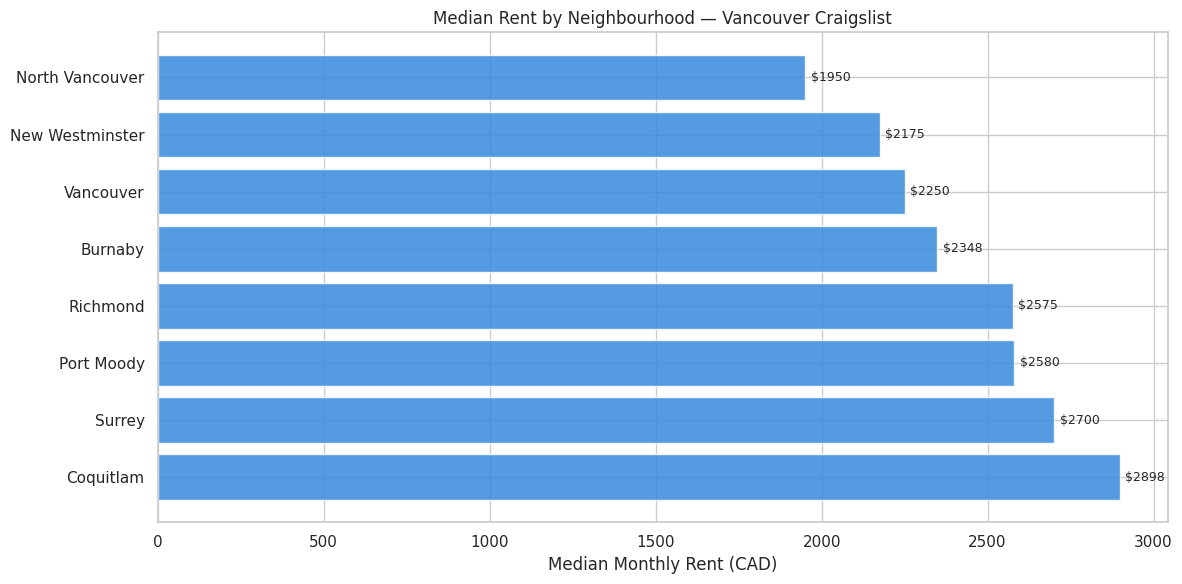

  neighbourhood  median_price  n_listings
      Coquitlam        2897.5          22
         Surrey        2700.0          21
     Port Moody        2580.0           7
       Richmond        2575.0          19
        Burnaby        2347.5          44
      Vancouver        2250.0         157
New Westminster        2175.0          12
North Vancouver        1950.0          17


In [29]:
hood_stats = (df.groupby('neighbourhood')['price']
               .agg(['median', 'count'])
               .rename(columns={'median':'median_price', 'count':'n_listings'})
               .query('n_listings >= 5')
               .sort_values('median_price', ascending=False)
               .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(hood_stats['neighbourhood'], hood_stats['median_price'],
               color=COLORS[0], alpha=0.85)
ax.set_xlabel('Median Monthly Rent (CAD)')
ax.set_title('Median Rent by Neighbourhood — Vancouver Craigslist')
ax.bar_label(bars, fmt='$%.0f', padding=4, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/01_rent_by_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()
print(hood_stats.to_string(index=False))

Price drop per km from SkyTrain: $-9


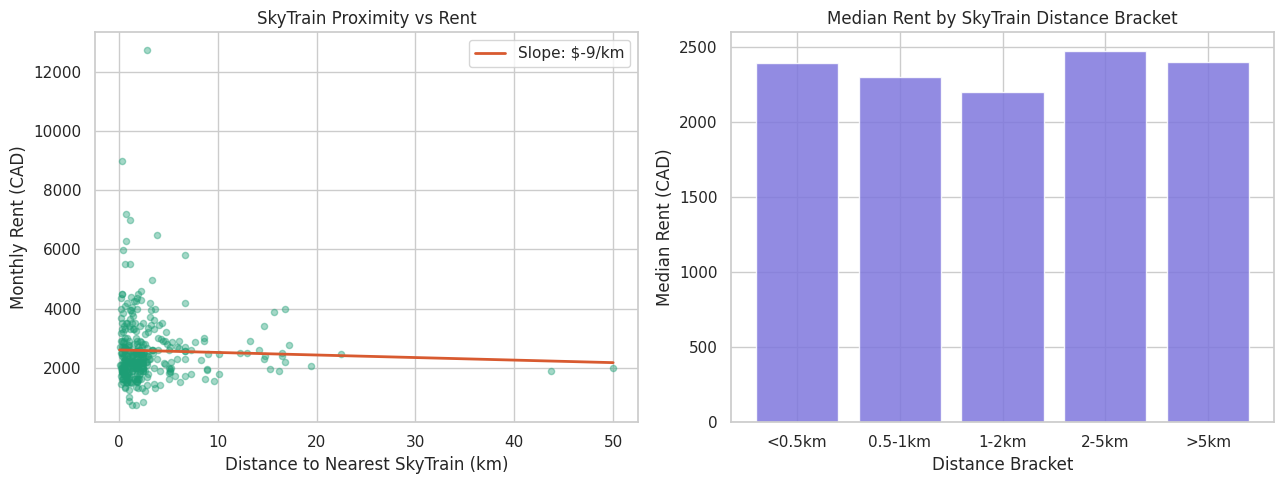

In [30]:
df_geo = df.dropna(subset=['skytrain_km', 'price'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter: distance vs price
axes[0].scatter(df_geo['skytrain_km'], df_geo['price'],
                alpha=0.4, s=20, color=COLORS[1])
m, b = np.polyfit(df_geo['skytrain_km'], df_geo['price'], 1)
x_line = np.linspace(df_geo['skytrain_km'].min(), df_geo['skytrain_km'].max(), 100)
axes[0].plot(x_line, m*x_line+b, color=COLORS[2], linewidth=2, label=f'Slope: ${m:.0f}/km')
axes[0].set_xlabel('Distance to Nearest SkyTrain (km)')
axes[0].set_ylabel('Monthly Rent (CAD)')
axes[0].set_title('SkyTrain Proximity vs Rent')
axes[0].legend()
print(f"Price drop per km from SkyTrain: ${m:.0f}")

# bin by distance bracket
df_geo['dist_bin'] = pd.cut(df_geo['skytrain_km'],
                             bins=[0,0.5,1,2,5,99],
                             labels=['<0.5km','0.5-1km','1-2km','2-5km','>5km'])
bin_median = df_geo.groupby('dist_bin')['price'].median()
axes[1].bar(bin_median.index, bin_median.values, color=COLORS[3], alpha=0.85)
axes[1].set_xlabel('Distance Bracket')
axes[1].set_ylabel('Median Rent (CAD)')
axes[1].set_title('Median Rent by SkyTrain Distance Bracket')

plt.tight_layout()
plt.savefig('outputs/02_skytrain_vs_rent.png', dpi=150, bbox_inches='tight')
plt.show()

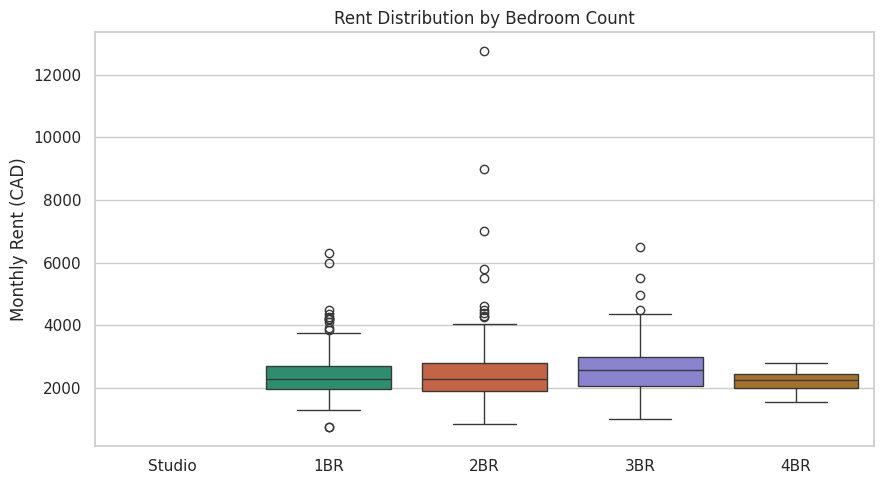

               median  count
bedroom_label               
1BR            2297.5    136
2BR            2272.5    126
3BR            2580.0     41
4BR            2250.0      5
5BR+           2800.0      7


In [31]:
df_br = df.dropna(subset=['bedrooms'])
df_br = df_br[df_br['bedrooms'].between(0, 5)]
df_br['bedroom_label'] = df_br['bedrooms'].map({
    0: 'Studio', 1: '1BR', 2: '2BR', 3: '3BR',
    4: '4BR', 5: '5BR+'
})

fig, ax = plt.subplots(figsize=(9, 5))
order = ['Studio', '1BR', '2BR', '3BR', '4BR']
sns.boxplot(data=df_br[df_br['bedroom_label'].isin(order)],
            x='bedroom_label', y='price', order=order,
            palette=COLORS[:5], ax=ax)
ax.set_title('Rent Distribution by Bedroom Count')
ax.set_xlabel(''); ax.set_ylabel('Monthly Rent (CAD)')
plt.tight_layout()
plt.savefig('outputs/03_rent_by_bedrooms.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_br.groupby('bedroom_label')['price'].agg(['median', 'count']))

MAE: $784  |  R²: -0.110


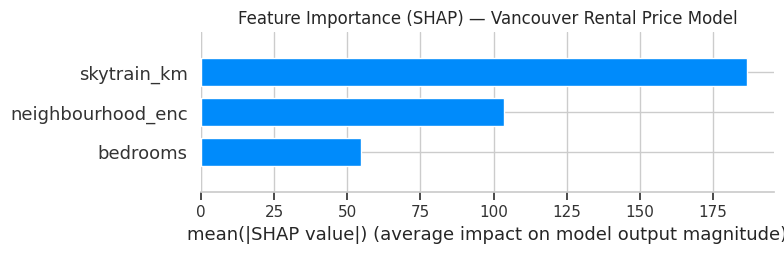

In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor

# sqft is all NaN so drop it from features
features = ['bedrooms', 'skytrain_km', 'neighbourhood_enc']

df_model = df.dropna(subset=['price', 'bedrooms', 'skytrain_km']).copy()
le = LabelEncoder()
df_model['neighbourhood_enc'] = le.fit_transform(
    df_model['neighbourhood'].fillna('Unknown'))

X = df_model[features]
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# HistGradientBoosting handles NaN natively and is faster
model = HistGradientBoostingRegressor(max_iter=200, max_depth=4,
                                      learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)
print(f"MAE: ${mae:.0f}  |  R²: {r2:.3f}")

# SHAP
explainer   = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_values, X_test, feature_names=features,
                  plot_type='bar', show=False)
plt.title('Feature Importance (SHAP) — Vancouver Rental Price Model')
plt.tight_layout()
plt.savefig('outputs/04_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

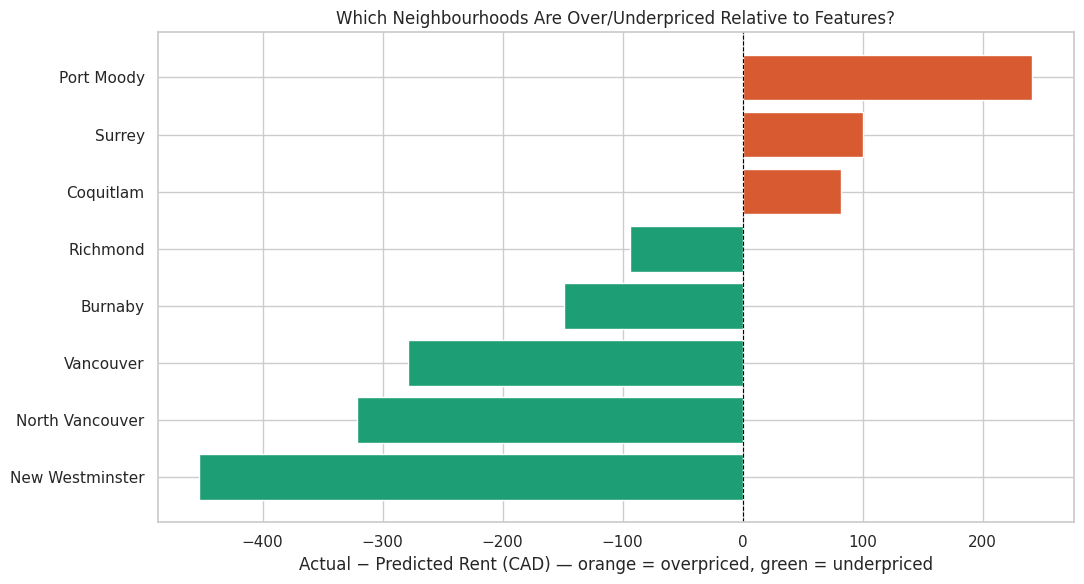

Most underpriced neighbourhoods:
  neighbourhood  median_residual   n
New Westminster      -452.636923   9
North Vancouver      -321.635752  17
      Vancouver      -278.788355 138
        Burnaby      -148.790165  43
       Richmond       -93.610050  19

Most overpriced neighbourhoods:
neighbourhood  median_residual  n
      Burnaby      -148.790165 43
     Richmond       -93.610050 19
    Coquitlam        82.107816 22
       Surrey       100.540695 21
   Port Moody       241.373475  7


In [34]:
# compare actual median vs model-predicted median per neighbourhood
df_model['predicted'] = model.predict(X)
df_model['residual']  = df_model['price'] - df_model['predicted']

hood_residuals = (df_model.groupby('neighbourhood')['residual']
                  .agg(['median', 'count'])
                  .query('count >= 5')
                  .sort_values('median')
                  .reset_index())
hood_residuals.columns = ['neighbourhood', 'median_residual', 'n']

colors_bar = [COLORS[2] if x > 0 else COLORS[1]
              for x in hood_residuals['median_residual']]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(hood_residuals['neighbourhood'],
        hood_residuals['median_residual'], color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Actual − Predicted Rent (CAD) — orange = overpriced, green = underpriced')
ax.set_title('Which Neighbourhoods Are Over/Underpriced Relative to Features?')
plt.tight_layout()
plt.savefig('outputs/05_over_underpriced.png', dpi=150, bbox_inches='tight')
plt.show()

print("Most underpriced neighbourhoods:")
print(hood_residuals.head(5).to_string(index=False))
print("\nMost overpriced neighbourhoods:")
print(hood_residuals.tail(5).to_string(index=False))

In [37]:
fmap = folium.Map(location=[49.25, -123.10], zoom_start=11, tiles='CartoDB positron')

# add skytrain stations
for _, s in skytrain_stations.iterrows():
    folium.Marker(
        location=[s['lat'], s['lon']],
        popup=s['station'],
        icon=folium.Icon(icon='info-sign', color='blue')
    ).add_to(fmap)

# add neighbourhood circles
for _, row in hood_residuals.iterrows():
    hood_df = df_model[df_model['neighbourhood'] == row['neighbourhood']]
    if hood_df.empty:
        continue
    lat = hood_df['lat'].mean()
    lon = hood_df['lon'].mean()
    if pd.isna(lat) or pd.isna(lon):
        continue

    color = 'red' if row['median_residual'] > 0 else 'green'
    popup_text = "{} | Residual: ${:.0f} | Listings: {}".format(
        row['neighbourhood'], row['median_residual'], row['n'])

    folium.CircleMarker(
        location=[lat, lon],
        radius=10,
        color=color, fill=True, fill_opacity=0.7,
        popup=popup_text
    ).add_to(fmap)

fmap.save('outputs/06_vancouver_rental_map.html')
fmap

In [39]:
!pip install pandasql -q

  Preparing metadata (setup.py) ... done


In [41]:
import sqlite3

conn = sqlite3.connect('vancouver_rentals.db')
df_model.to_sql('rentals', conn, if_exists='replace', index=False)

q1 = """
SELECT neighbourhood,
       ROUND(AVG(price), 0) AS avg_rent,
       COUNT(*)             AS listings
FROM rentals
GROUP BY neighbourhood
HAVING listings >= 5
ORDER BY avg_rent DESC
"""

q2 = """
SELECT bedrooms,
       ROUND(AVG(price), 0) AS avg_rent,
       COUNT(*)             AS listings
FROM rentals
WHERE bedrooms BETWEEN 0 AND 4
GROUP BY bedrooms
ORDER BY bedrooms
"""

q3 = """
SELECT
    CASE WHEN skytrain_km < 1 THEN 'Within 1km'
         WHEN skytrain_km < 2 THEN '1-2km'
         ELSE 'Over 2km' END AS transit_proximity,
    ROUND(AVG(price), 0)    AS avg_rent,
    COUNT(*)                AS listings
FROM rentals
WHERE skytrain_km IS NOT NULL
GROUP BY transit_proximity
ORDER BY avg_rent DESC
"""

q4 = """
SELECT neighbourhood,
       ROUND(AVG(price), 0)       AS avg_rent,
       ROUND(AVG(skytrain_km), 2) AS avg_skytrain_km,
       COUNT(*)                   AS listings
FROM rentals
WHERE skytrain_km IS NOT NULL
GROUP BY neighbourhood
HAVING listings >= 5
ORDER BY avg_rent ASC, avg_skytrain_km ASC
LIMIT 10
"""

print("=== Q1: Average rent by neighbourhood ===")
print(pd.read_sql(q1, conn).to_string(index=False))

print("\n=== Q2: Rent by bedroom count ===")
print(pd.read_sql(q2, conn).to_string(index=False))

print("\n=== Q3: SkyTrain proximity premium ===")
print(pd.read_sql(q3, conn).to_string(index=False))

print("\n=== Q4: Best value neighbourhoods ===")
print(pd.read_sql(q4, conn).to_string(index=False))

conn.close()

=== Q1: Average rent by neighbourhood ===
  neighbourhood  avg_rent  listings
     Port Moody    3118.0         7
         Surrey    2908.0        21
      Coquitlam    2724.0        22
       Richmond    2580.0        19
      Vancouver    2569.0       138
New Westminster    2495.0         9
        Burnaby    2452.0        43
North Vancouver    2206.0        17

=== Q2: Rent by bedroom count ===
 bedrooms  avg_rent  listings
      1.0    2476.0       136
      2.0    2595.0       126
      3.0    2798.0        41
      4.0    2208.0         5

=== Q3: SkyTrain proximity premium ===
transit_proximity  avg_rent  listings
       Within 1km    2611.0        88
         Over 2km    2578.0       144
            1-2km    2512.0        85

=== Q4: Best value neighbourhoods ===
  neighbourhood  avg_rent  avg_skytrain_km  listings
North Vancouver    2206.0             5.93        17
        Burnaby    2452.0             1.71        43
New Westminster    2495.0             0.99         9
      

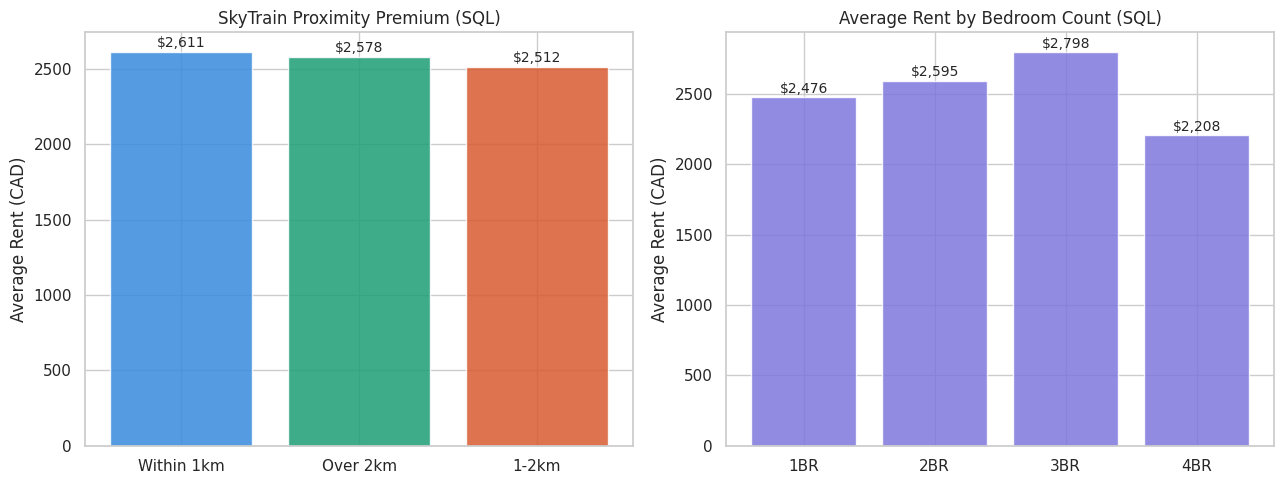

In [42]:
conn = sqlite3.connect('vancouver_rentals.db')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# plot Q3: transit premium
q3_df = pd.read_sql(q3, conn)
axes[0].bar(q3_df['transit_proximity'], q3_df['avg_rent'],
            color=COLORS[:3], alpha=0.85)
axes[0].set_title('SkyTrain Proximity Premium (SQL)')
axes[0].set_ylabel('Average Rent (CAD)')
for i, v in enumerate(q3_df['avg_rent']):
    axes[0].text(i, v + 30, f'${v:,.0f}', ha='center', fontsize=10)

# plot Q2: bedroom premium
q2_df = pd.read_sql(q2, conn)
q2_df['bedroom_label'] = q2_df['bedrooms'].map(
    {0:'Studio', 1:'1BR', 2:'2BR', 3:'3BR', 4:'4BR'})
axes[1].bar(q2_df['bedroom_label'], q2_df['avg_rent'],
            color=COLORS[3], alpha=0.85)
axes[1].set_title('Average Rent by Bedroom Count (SQL)')
axes[1].set_ylabel('Average Rent (CAD)')
for i, v in enumerate(q2_df['avg_rent']):
    axes[1].text(i, v + 30, f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/07_sql_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
conn.close()

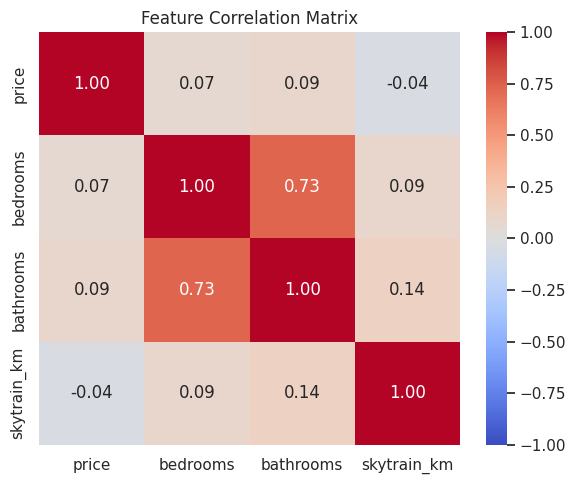

In [43]:
corr_cols = ['price', 'bedrooms', 'bathrooms', 'skytrain_km']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

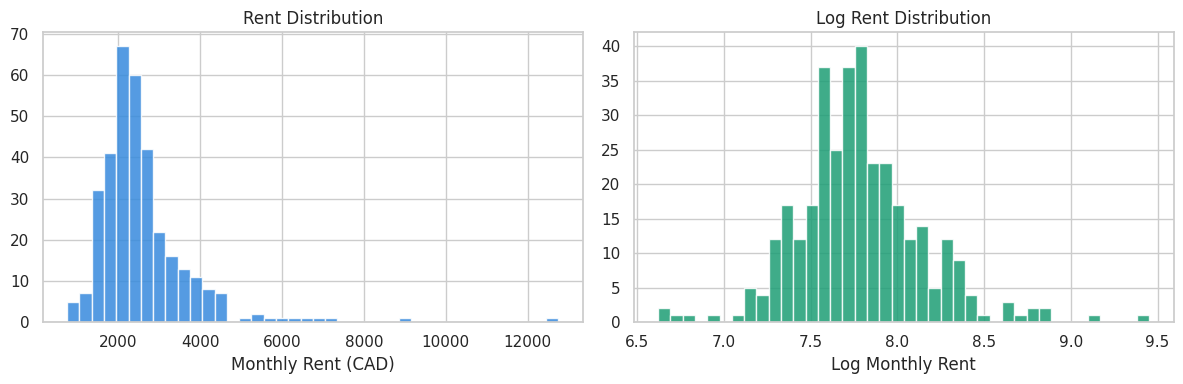

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=40, color=COLORS[0], alpha=0.85, edgecolor='white')
axes[0].set_title('Rent Distribution')
axes[0].set_xlabel('Monthly Rent (CAD)')
axes[1].hist(np.log1p(df['price']), bins=40, color=COLORS[1], alpha=0.85, edgecolor='white')
axes[1].set_title('Log Rent Distribution')
axes[1].set_xlabel('Log Monthly Rent')
plt.tight_layout()
plt.savefig('outputs/00_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()